# Laboratorium 6 - Zastosowanie wielomianów ortogonalnych w medycynie obliczeniowej
Jakub Fabia

## Biblioteki

In [11]:
using Plots
using Polynomials
using SpecialPolynomials
using LinearAlgebra
using CSV
using DataFrames
using Statistics

## Zadanie 1 - Wielomiany Hermita

In [22]:
function base_fun(k, x, norm)
    H_k = basis(Hermite, k).(x)
    app = H_k .* exp.(-(x.^2)/2)
    if norm
        return normalize(app)
    end
    return app
end

base_fun (generic function with 1 method)

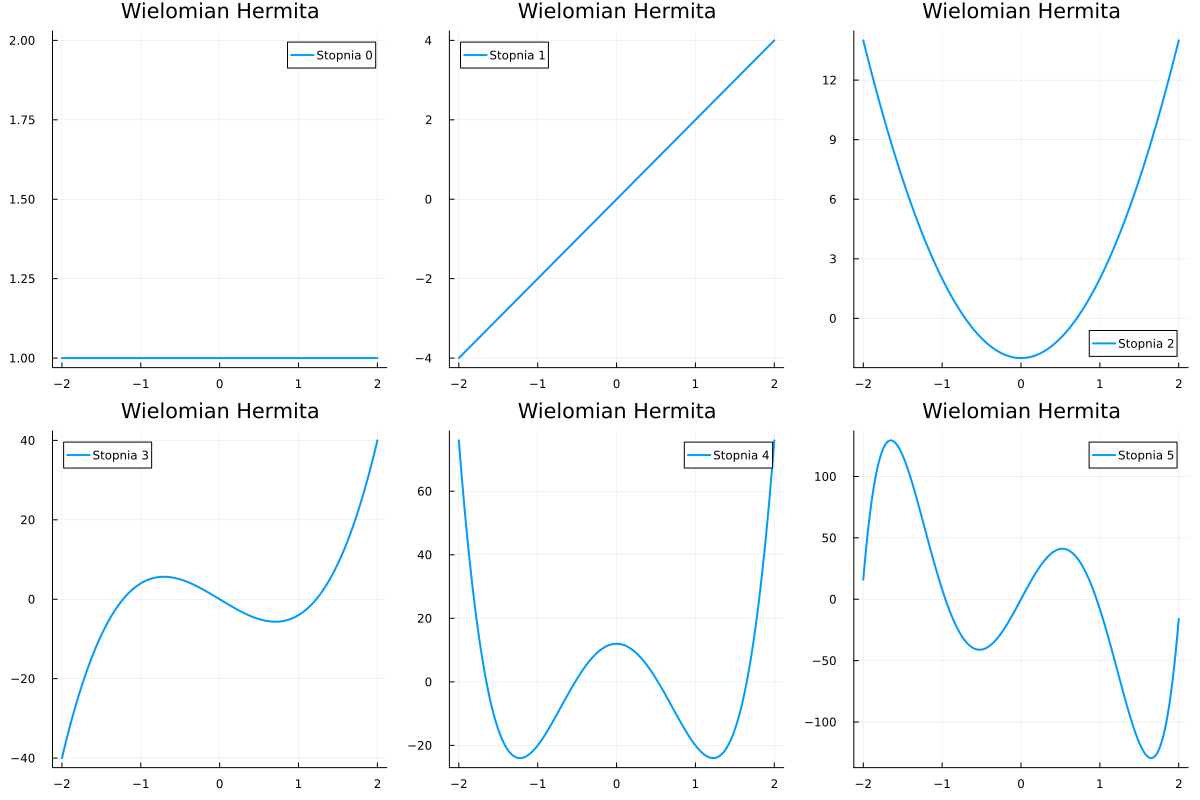

In [3]:
x_range = -2:0.01:2
plot_arr = []
for k in 0:5
    y = [basis(Hermite, k).(x) for x in x_range]
    push!(plot_arr, plot(x_range, y, linewidth=2, label="Stopnia $k"))
end

plot(plot_arr..., layout=(2, 3), size=(1200, 800), title="Wielomian Hermita")

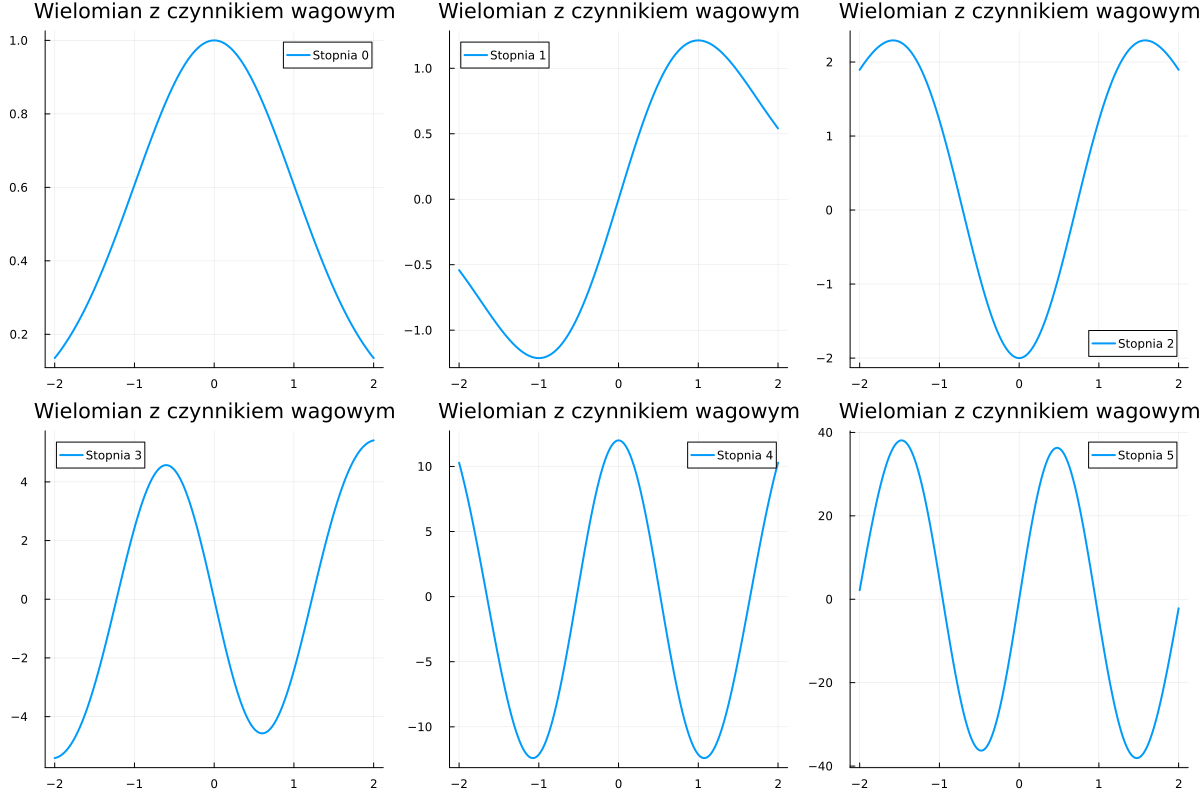

In [4]:
x_range = -2:0.01:2
plot_arr = []
for k in 0:5
    y = [base_fun(k, x, false) for x in x_range]
    push!(plot_arr, plot(x_range, y, linewidth=2, label="Stopnia $k"))
end
plot(plot_arr..., layout=(2, 3), size=(1200, 800), title="Wielomian z czynnikiem wagowym")

## Zadanie 2 - Ortogonalność Wielomianów

In [5]:
x_range = -10:0.1:10

-10.0:0.1:10.0

In [6]:
fun_arr = []
for k in 0:5
    push!(fun_arr, [basis(Hermite, k).(x) for x in x_range])
end
dot_base = Array{Float64, 2}(undef, 6, 6);
for (i, f_i) in enumerate(fun_arr) 
    for (j, f_j) in enumerate(fun_arr)
        dot_base[i,j] = dot(f_i, f_j)
    end
end
round.(dot_base, digits=2)

6×6 Matrix{Float64}:
   201.0            0.0        …   0.0         6.23866e6   0.0
     0.0        27068.0            6.39866e6   0.0         1.76361e9
 26666.0            0.0           -0.0         1.80233e9   0.0
     0.0            6.39866e6      1.81545e9   0.0         5.46778e11
     6.23866e6      0.0            0.0         5.50488e11  0.0
     0.0            1.76361e9  …   5.46778e11  0.0         1.73768e14

Widać, że wielomiany nie są ortogonalne, ponieważ poza przekątną główną są liczby inne niż 0, a na przekątnej głównej są liczby różne od 1.

In [7]:
fun_arr = []
for k in 0:5
    push!(fun_arr, base_fun(k, x_range, true))
end
dot_base = Array{Float64, 2}(undef, 6, 6);
for (i, f_i) in enumerate(fun_arr) 
    for (j, f_j) in enumerate(fun_arr)
        dot_base[i,j] = dot(f_i, f_j)
    end
end
round.(dot_base, digits=2)

6×6 Matrix{Float64}:
  1.0  -0.0   0.0   0.0   0.0   0.0
 -0.0   1.0   0.0   0.0   0.0  -0.0
  0.0   0.0   1.0  -0.0   0.0  -0.0
  0.0   0.0  -0.0   1.0   0.0   0.0
  0.0   0.0   0.0   0.0   1.0  -0.0
  0.0  -0.0  -0.0   0.0  -0.0   1.0

Wielomiany są ortogonalne.

## Zadanie 3 - Aproksymacja zespołu QRS

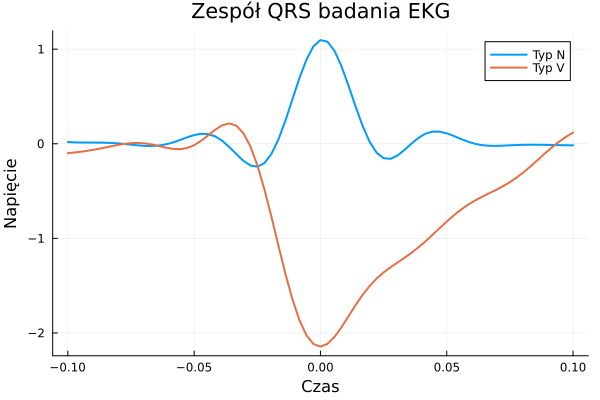

In [12]:
ekg_data = CSV.read("ecg_data.csv", DataFrame)
plot(ekg_data.time, ekg_data.signalN, label="Typ N", xlabel = "Czas", linewidth=2, ylabel="Napięcie", title="Zespół QRS badania EKG")
plot!(ekg_data.time, ekg_data.signalV, linewidth=2, label="Typ V")

In [13]:
xx_ekg = ekg_data.time*40
yy_ekgV = ekg_data.signalV;
yy_ekgN = ekg_data.signalN;
MAX_APPROX_DEGREE = 10

10

In [23]:
Vapprox = []

for k in 0:MAX_APPROX_DEGREE
    fun = base_fun(k, xx_ekg, true)
    fun_dot = dot(yy_ekgV, fun)
    val = fun_dot * fun
    if k == 0
        push!(Vapprox, val)
    else
        push!(Vapprox, val + Vapprox[end])
    end
end

In [24]:
Napprox = []

for k in 0:MAX_APPROX_DEGREE
    fun = base_fun(k, xx_ekg, true)
    fun_dot = dot(yy_ekgN, fun)
    val = fun_dot * fun
    if k == 0
        push!(Napprox, val)
    else
        push!(Napprox, val + Napprox[end])
    end
end

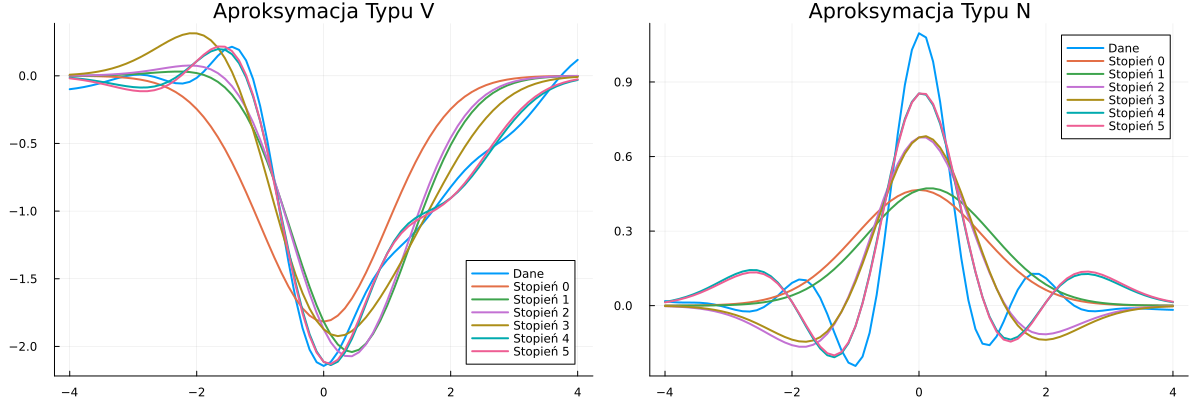

In [25]:
p1 = plot(
    xx_ekg, 
    [yy_ekgV ,Vapprox[1:6]],
    label=["Dane" "Stopień 0" "Stopień 1" "Stopień 2" "Stopień 3" "Stopień 4" "Stopień 5"],
    linewidth=2,
    title="Aproksymacja Typu V"
)

p2 = plot(
    xx_ekg, 
    [yy_ekgN, Napprox[1:6]],
    label=["Dane" "Stopień 0" "Stopień 1" "Stopień 2" "Stopień 3" "Stopień 4" "Stopień 5"],
    linewidth=2,
    title="Aproksymacja Typu N"
)

plot(p1,p2, layout=(1,2), size=(1200, 400))

## Zadanie 4 - Błąd Aproksymacji

In [26]:
mse(y1, y2) = mean((y1-y2).^2)

mse (generic function with 1 method)

In [27]:
Nepsilon = []
for approx in Napprox
    push!(Nepsilon, mse(yy_ekgN, approx))
end

In [28]:
Vepsilon = []
for approx in Vapprox
    push!(Vepsilon, mse(yy_ekgV, approx))
end

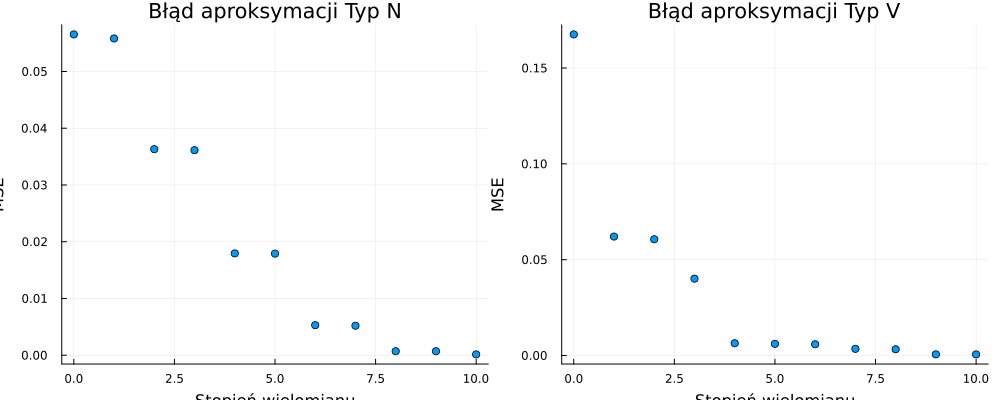

In [29]:
p1 = scatter( 
    0:1:MAX_APPROX_DEGREE,
    Nepsilon,
    xlabel="Stopień wielomianu",
    ylabel="MSE",
    legend = false,
    title="Błąd aproksymacji Typ N"
)

p2 = scatter( 
    0:1:MAX_APPROX_DEGREE,
    Vepsilon,
    xlabel="Stopień wielomianu",
    ylabel="MSE",
    legend = false,
    title="Błąd aproksymacji Typ V"
)

plot(p1,p2, layout=(1,2), size=(1000, 400))

In [30]:
min_index_Vepsilon = argmin(Vepsilon) - 1
min_index_Nepsilon = argmin(Nepsilon) - 1

println("Stopień najlepszej aproksymacji dla typu V: ", min_index_Vepsilon)
println("Stopień najlepszej aproksymacji dla typu N: ", min_index_Nepsilon)

Stopień najlepszej aproksymacji dla typu V: 10
Stopień najlepszej aproksymacji dla typu N: 10
